In [1]:
# Understanding the Dataset

import pandas as pd

df = pd.read_csv("../data/AAPL_engineered.csv")

print(df.head())
print(df.columns)
print(df.info())
print(df.describe())




         date       open       high        low      close     volume  \
0  2016-05-13  20.526531  20.907412  20.526531  20.645128  177571200   
1  2016-05-16  21.071627  21.527773  20.902854  21.411455  245039200   
2  2016-05-17  21.564266  21.598476  21.213034  21.322508  187667600   
3  2016-05-18  21.475312  21.714787  21.413732  21.566540  168249600   
4  2016-05-19  21.584794  21.584794  21.340757  21.484442  121768400   

       rsi_7     rsi_14       cci_7      cci_14     sma_50     ema_50  \
0  18.165817  23.979977 -121.638643 -110.854532  23.417778  22.794850   
1  47.605299  38.529057   70.931992    1.472171  23.378976  22.740599   
2  45.393943  37.628871   83.412084   57.388288  23.343563  22.684988   
3  52.462071  41.656372  110.755574  136.677076  23.316839  22.641127   
4  49.925657  40.704101   69.665180   84.663171  23.288065  22.595767   

     sma_100    ema_100      macd  bollinger  TrueRange     atr_7    atr_14  \
0  22.886907  23.079897 -0.857738  24.981912   0.

In [2]:
print(f"Dataset Shape: {df.shape}\n")

print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2415, 20)

Missing Values:
date              0
open              0
high              0
low               0
close             0
volume            0
rsi_7             0
rsi_14            0
cci_7             0
cci_14            0
sma_50            0
ema_50            0
sma_100           0
ema_100           0
macd              0
bollinger         0
TrueRange         0
atr_7             0
atr_14            0
next_day_close    0
dtype: int64

Data Types:
date                  str
open              float64
high              float64
low               float64
close             float64
volume              int64
rsi_7             float64
rsi_14            float64
cci_7             float64
cci_14            float64
sma_50            float64
ema_50            float64
sma_100           float64
ema_100           float64
macd              float64
bollinger         float64
TrueRange         float64
atr_7             float64
atr_14            float64
next_day_close    float64
dtype: obje

In [3]:
print(df["date"].head())
print(df["date"].tail())


0    2016-05-13
1    2016-05-16
2    2016-05-17
3    2016-05-18
4    2016-05-19
Name: date, dtype: str
2410    2025-12-12
2411    2025-12-15
2412    2025-12-16
2413    2025-12-17
2414    2025-12-18
Name: date, dtype: str


In [4]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date              datetime64[us]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
rsi_7                    float64
rsi_14                   float64
cci_7                    float64
cci_14                   float64
sma_50                   float64
ema_50                   float64
sma_100                  float64
ema_100                  float64
macd                     float64
bollinger                float64
TrueRange                float64
atr_7                    float64
atr_14                   float64
next_day_close           float64
dtype: object


In [5]:
# Correlation Analysis: How strongly is each features related to tomorrow's closing price?

print(df.corr()["next_day_close"].sort_values(ascending=False))

next_day_close    1.000000
close             0.999449
high              0.999298
low               0.999297
open              0.999090
bollinger         0.995534
ema_50            0.994214
sma_50            0.992227
ema_100           0.990094
sma_100           0.985492
date              0.968995
atr_14            0.845578
atr_7             0.813459
TrueRange         0.641960
macd              0.226489
cci_7            -0.032718
cci_14           -0.040329
rsi_7            -0.058506
rsi_14           -0.065464
volume           -0.537128
Name: next_day_close, dtype: float64


In [6]:
# Features and Targets creation

X = df.drop(columns=["next_day_close", "date"])
y = df["next_day_close"]

print(X.head())
print(y.head())

        open       high        low      close     volume      rsi_7  \
0  20.526531  20.907412  20.526531  20.645128  177571200  18.165817   
1  21.071627  21.527773  20.902854  21.411455  245039200  47.605299   
2  21.564266  21.598476  21.213034  21.322508  187667600  45.393943   
3  21.475312  21.714787  21.413732  21.566540  168249600  52.462071   
4  21.584794  21.584794  21.340757  21.484442  121768400  49.925657   

      rsi_14       cci_7      cci_14     sma_50     ema_50    sma_100  \
0  23.979977 -121.638643 -110.854532  23.417778  22.794850  22.886907   
1  38.529057   70.931992    1.472171  23.378976  22.740599  22.859025   
2  37.628871   83.412084   57.388288  23.343563  22.684988  22.830480   
3  41.656372  110.755574  136.677076  23.316839  22.641127  22.801264   
4  40.704101   69.665180   84.663171  23.288065  22.595767  22.772534   

     ema_100      macd  bollinger  TrueRange     atr_7    atr_14  
0  23.079897 -0.857738  24.981912   0.380881  0.458302  0.473165  


###### *The feature matrix consisted of 18 predictor variables, including historical OHLCV data and engineered technical indicators (RSI, CCI, SMA, EMA, MACD, Bollinger Band, True Range, and ATR). The target variable was the next-day closing price (next_day_close). The date column was excluded because it served only as a temporal index and was not treated as a predictive feature.*

In [7]:
# Creating a Random Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(1932, 18)
(483, 18)
(1932,)
(483,)


##### At this point we have 1932 training rows, 483 testing rows and 18 input features for both. We have 1932 correct target values for training and 483 correct target values for testing. Our data is now ready for the first model.

## **Linear Regression - Random Split**

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])
print(y_test.head())

[ 37.70195502  31.98917166 135.13277456 194.60541067  84.77697038]
410      39.632290
199      32.359241
1670    123.211189
1934    193.353989
1036     85.757645
Name: next_day_close, dtype: float64


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr_random = mean_absolute_error(y_test, predictions)
mse_lr_random = mean_squared_error(y_test, predictions)
rmse_lr_random = mse_lr_random ** 0.5
r2_lr_random = r2_score(y_test, predictions)

print("MAE: ", mae_lr_random)
print("MSE: ", mse_lr_random)
print("RMSE: ", rmse_lr_random)
print("R2: ", r2_lr_random)



MAE:  3.270253945552896
MSE:  19.798572185368972
RMSE:  4.4495586506269325
R2:  0.9962468116009711


##### *In random train-test splitting, observations from different time periods are mixed together. As a result, the model may be trained on data from later years while being tested on earlier years, which does not reflect how financial forecasting works in practice. Since stock prices and market conditions are highly dependent on time, the model gains indirect knowledge of patterns across the entire decade. This can lead to overly optimistic performance estimates because the model is evaluated in an environment where information from future periods influences the learning process, making the prediction task easier than it would be in a real-world forecasting scenario.*

## **Linear Regression - Time Based**

In [10]:
# Inspecting the date range

print(df["date"].min())
print(df["date"].max())

# finding the 80% cutoff point now

split_index = int(len(df)*0.8)

print(split_index)
print(df.iloc[split_index]["date"])


2016-05-13 00:00:00
2025-12-18 00:00:00
1932
2024-01-18 00:00:00


In [11]:
# creating new training and testing data using chronological order

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

print(X_train_time.shape)
print(X_test_time.shape)
print(y_train_time.shape)
print(y_test_time.shape)



(1932, 18)
(483, 18)
(1932,)
(483,)


In [12]:
from sklearn.linear_model import LinearRegression

time_model = LinearRegression()

time_model.fit(X_train_time, y_train_time)

time_predictions = time_model.predict(X_test_time)

print(time_predictions[:5])
print(y_test_time.head())


[189.52609655 191.94941616 193.73269312 193.66132844 193.17360589]
1932    189.767853
1933    192.076035
1934    193.353989
1935    192.680344
1936    192.353424
Name: next_day_close, dtype: float64


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr_time = mean_absolute_error(y_test_time, time_predictions)
mse_lr_time = mean_squared_error(y_test_time, time_predictions)
rmse_lr_time = mse_lr_time ** 0.5
r2_lr_time = r2_score(y_test_time, time_predictions)

print("MAE:", mae_lr_time)
print("MSE:", mse_lr_time)
print("RMSE:", rmse_lr_time)
print("R2:", r2_lr_time)

MAE: 5.71508908481005
MSE: 53.750128714901486
RMSE: 7.3314479275857565
R2: 0.9333656435425824


###### Linear Regression achieved stronger performance under random train-test splitting (MAE = 3.270253945552896, RMSE = 4.4495586506269325, R² = 0.9962468116009711) than under chronological time-based validation (MAE = 5.71508908481005, RMSE = 7.3314479275857565, R² = 0.9333656435425824). The increase in prediction error suggests that random splitting may provide overly optimistic estimates of model performance by allowing the model to learn patterns from multiple market periods that would not be available in a real forecasting scenario.

### **Decision Tree - Random**

In [14]:
# importing decision tree

from sklearn.tree import DecisionTreeRegressor

dt_random = DecisionTreeRegressor(random_state=42)

dt_random.fit(X_train, y_train)

dt_random_predictions = dt_random.predict(X_test)

print(dt_random_predictions[:5])
print(y_test.head())

[ 40.54799271  31.60460281 127.99899292 190.81375122  88.2991333 ]
410      39.632290
199      32.359241
1670    123.211189
1934    193.353989
1036     85.757645
Name: next_day_close, dtype: float64


In [15]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_random = mean_absolute_error(y_test, dt_random_predictions)
mse_dt_random = mean_squared_error(y_test, dt_random_predictions)
rmse_dt_random = mse_dt_random ** 0.5
r2_dt_random = r2_score(y_test, dt_random_predictions)

print("MAE:", mae_dt_random)
print("RMSE:", rmse_dt_random)
print("R2:", r2_dt_random)


MAE: 2.1524840763636996
RMSE: 3.3807335861675063
R2: 0.9978333518505899


### **Decision Tree - Time Based**

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt_time = DecisionTreeRegressor(random_state=42)
dt_time.fit(X_train_time, y_train_time)

dt_time_predictions = dt_time.predict(X_test_time)

In [17]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_time = mean_absolute_error(y_test_time, dt_time_predictions)
mse_dt_time = mean_squared_error(y_test_time, dt_time_predictions)
rmse_dt_time = mse_dt_time ** 0.5
r2_dt_time = r2_score(y_test_time, dt_time_predictions)

print("MAE:", mae_dt_time)
print("RMSE:", rmse_dt_time)
print("R2:", r2_dt_time)

MAE: 27.728184607211617
RMSE: 35.85868771699917
R2: -0.5940703479392473


In [18]:
print("Training target range:")
print(y_train_time.min(), y_train_time.max())

print("\nTesting target range:")
print(y_test_time.min(), y_test_time.max())

print("\nPrediction range:")
print(dt_time_predictions.min(), dt_time_predictions.max())

Training target range:
20.99180030822754 196.25656127929688

Testing target range:
163.66488647460938 286.19000244140625

Prediction range:
162.81454467773438 195.7216339111328


In [19]:
comparison_dt_time = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "actual": y_test_time.values,
    "predicted": dt_time_predictions
})

print(comparison_dt_time.head())
print(comparison_dt_time.tail())
print(comparison_dt_time.describe())

        date      actual   predicted
0 2024-01-18  189.767853  183.903229
1 2024-01-19  192.076035  183.903229
2 2024-01-22  193.353989  195.721634
3 2024-01-23  192.680344  195.721634
4 2024-01-24  192.353424  195.721634
          date      actual   predicted
478 2025-12-12  274.109985  195.097504
479 2025-12-15  274.609985  195.097504
480 2025-12-16  271.839996  195.097504
481 2025-12-17  272.190002  195.097504
482 2025-12-18  273.670013  195.097504
                             date      actual   predicted
count                         483  483.000000  483.000000
mean   2025-01-02 15:51:03.354037  218.864515  191.808215
min           2024-01-18 00:00:00  163.664886  162.814545
25%           2024-07-11 12:00:00  199.294617  195.097504
50%           2025-01-02 00:00:00  221.373016  195.097504
75%           2025-06-28 12:00:00  235.031708  195.721634
max           2025-12-18 00:00:00  286.190002  195.721634
std                           NaN   28.430906    8.127643


#### At this point the data is suggesting that:

##### More flexible models may benefit more from random validation and suffer larger performance degradation under realistic time-based validation.

###### The Decision Tree failed to generalize under chronological validation because it could not extrapolate beyond the target values observed during training. The training period contained next-day closing prices up to approximately $196, while the test period reached approximately $286. Correspondingly, the Decision Tree never predicted values above $196, producing systematic underestimation throughout the later portion of the test period. This resulted in an RMSE of 35.86 and a negative R² (-0.594), despite achieving excellent performance under random validation.

### **Random Forest - Random**

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train, y_train)

rf_random_predictions = rf_random.predict(X_test)

In [21]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_random = mean_absolute_error(y_test, rf_random_predictions)
mse_rf_random  = mean_squared_error(y_test, rf_random_predictions)
rmse_rf_random = mse_rf_random ** 0.5
r2_rf_random = r2_score(y_test, rf_random_predictions)

print("MAE:", mae_rf_random)
print("RMSE:", rmse_rf_random)
print("R2:", r2_rf_random)

MAE: 1.6884508062643055
RMSE: 2.7139396781753353
R2: 0.9986037381404609


### **Random Forest - Time Based**

In [22]:
rf_time = RandomForestRegressor(n_estimators = 100, random_state = 42)

rf_time.fit(X_train_time, y_train_time)

rf_time_predictions = rf_time.predict(X_test_time)

In [23]:
# Evaluation

mae_rf_time = mean_absolute_error(y_test_time, rf_time_predictions)
mse_rf_time = mean_squared_error(y_test_time, rf_time_predictions)
rmse_rf_time = mse_rf_time ** 0.5
r2_rf_time = r2_score(y_test_time, rf_time_predictions)

print("MAE:", mae_rf_time)
print("RMSE:", rmse_rf_time)
print("R2:", r2_rf_time)


MAE: 28.805249282173484
RMSE: 37.10266047307096
R2: -0.7065884553493553


In [24]:
print("Training max:", y_train_time.max())
print("Testing max:", y_test_time.max())

print("Prediction min:", rf_time_predictions.min())
print("Prediction max:", rf_time_predictions.max())

Training max: 196.25656127929688
Testing max: 286.19000244140625
Prediction min: 165.13894149780273
Prediction max: 195.35370727539063


In [25]:
comparison_rf = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "actual": y_test_time.values,
    "predicted": rf_time_predictions
})

print(comparison_rf.head())
print(comparison_rf.tail())
print(comparison_rf.describe())

        date      actual   predicted
0 2024-01-18  189.767853  183.422793
1 2024-01-19  192.076035  185.110371
2 2024-01-22  193.353989  193.004347
3 2024-01-23  192.680344  193.036127
4 2024-01-24  192.353424  193.078848
          date      actual   predicted
478 2025-12-12  274.109985  193.633345
479 2025-12-15  274.609985  193.198947
480 2025-12-16  271.839996  193.097077
481 2025-12-17  272.190002  193.193725
482 2025-12-18  273.670013  193.066313
                             date      actual   predicted
count                         483  483.000000  483.000000
mean   2025-01-02 15:51:03.354037  218.864515  190.468964
min           2024-01-18 00:00:00  163.664886  165.138941
25%           2024-07-11 12:00:00  199.294617  193.123853
50%           2025-01-02 00:00:00  221.373016  193.474091
75%           2025-06-28 12:00:00  235.031708  193.999896
max           2025-12-18 00:00:00  286.190002  195.353707
std                           NaN   28.430906    7.385040


## **Walk-Forward Validation or Expanding Window Validation**

In [26]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print("TRAIN:", len(train_index))
    print("TEST:", len(test_index))
    print("----------------------")

TRAIN: 405
TEST: 402
----------------------
TRAIN: 807
TEST: 402
----------------------
TRAIN: 1209
TEST: 402
----------------------
TRAIN: 1611
TEST: 402
----------------------
TRAIN: 2013
TEST: 402
----------------------


In [27]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
    print(f"Fold {fold}")

    print(
        "Training:",
        df.iloc[train_index[0]]["date"],
        "to",
        df.iloc[train_index[-1]]["date"]
    )

    print(
        "Testing:",
        df.iloc[test_index[0]]["date"],
        "to",
        df.iloc[test_index[-1]]["date"]
    )

    print("Training rows:", len(train_index))
    print("Testing rows:", len(test_index))
    print("-" * 50)

Fold 1
Training: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Testing: 2017-12-20 00:00:00 to 2019-07-29 00:00:00
Training rows: 405
Testing rows: 402
--------------------------------------------------
Fold 2
Training: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Testing: 2019-07-30 00:00:00 to 2021-03-03 00:00:00
Training rows: 807
Testing rows: 402
--------------------------------------------------
Fold 3
Training: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Testing: 2021-03-04 00:00:00 to 2022-10-05 00:00:00
Training rows: 1209
Testing rows: 402
--------------------------------------------------
Fold 4
Training: 2016-05-13 00:00:00 to 2022-10-05 00:00:00
Testing: 2022-10-06 00:00:00 to 2024-05-13 00:00:00
Training rows: 1611
Testing rows: 402
--------------------------------------------------
Fold 5
Training: 2016-05-13 00:00:00 to 2024-05-13 00:00:00
Testing: 2024-05-14 00:00:00 to 2025-12-18 00:00:00
Training rows: 2013
Testing rows: 402
------------------------------------------------

#### **Linear Regression - Walk-Forward Validation**

In [28]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)
    
    predictions_lr_wf = model.predict(X_test_fold)
    
    mae_scores.append(mean_absolute_error(y_test_fold, predictions_lr_wf))
    
    rmse_lr_wf = mean_squared_error(
    y_test_fold,
    predictions_lr_wf
    ) ** 0.5

    print("Fold RMSE:", rmse_lr_wf)
    rmse_scores.append(rmse_lr_wf)
    
    r2_scores.append(r2_score(y_test_fold, predictions_lr_wf))
lr_fold_rmse = rmse_scores.copy()
mean_rmse_lr_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_lr_wf)
print("Average R2:", np.mean(r2_scores))


Fold RMSE: 14.64210882031741
Fold RMSE: 56.38437355802549
Fold RMSE: 6.461666199785836
Fold RMSE: 4.825426841754899
Fold RMSE: 7.8449864577590835
Average MAE: 15.745431126048112
Average RMSE: 18.031712375528546
Average R2: -1.8705909724707286


In [29]:
for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)

    pred = model.predict(X_test_fold)

    print(f"\n========== Fold {fold} ==========")
    print(
        "Train dates:",
        df.iloc[train_index[0]]["date"],
        "to",
        df.iloc[train_index[-1]]["date"]
    )
    print(
        "Test dates:",
        df.iloc[test_index[0]]["date"],
        "to",
        df.iloc[test_index[-1]]["date"]
    )

    print(
        "Train target range:",
        y_train_fold.min(),
        "->",
        y_train_fold.max()
    )
    print(
        "Test target range:",
        y_test_fold.min(),
        "->",
        y_test_fold.max()
    )

    print("MAE:", mean_absolute_error(y_test_fold, pred))
    print("RMSE:", mean_squared_error(y_test_fold, pred) ** 0.5)
    print("R²:", r2_score(y_test_fold, pred))
    
print("\nMean RMSE:", np.mean(rmse_scores))
print("Median RMSE:", np.median(rmse_scores))
print("Std RMSE:", np.std(rmse_scores))


========== Fold 1 ==========
Train dates: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Test dates: 2017-12-20 00:00:00 to 2019-07-29 00:00:00
Train target range: 20.99180030822754 -> 41.31612396240234
Test target range: 33.7996711730957 -> 54.97304534912109
MAE: 13.910730447285186
RMSE: 14.64210882031741
R²: -8.634897143615158

========== Fold 2 ==========
Train dates: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Test dates: 2019-07-30 00:00:00 to 2021-03-03 00:00:00
Train target range: 20.99180030822754 -> 54.97304534912109
Test target range: 46.33326721191406 -> 139.3594512939453
MAE: 49.52687348899692
RMSE: 56.38437355802549
R²: -3.3640064076768175

========== Fold 3 ==========
Train dates: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Test dates: 2021-03-04 00:00:00 to 2022-10-05 00:00:00
Train target range: 20.99180030822754 -> 139.3594512939453
Test target range: 113.44017791748048 -> 178.27029418945312
MAE: 5.046281489011535
RMSE: 6.461666199785836
R²: 0.8318290839384388

========== F

###### Under expanding-window validation, Linear Regression achieved an average RMSE of 18.03 across five folds. Performance varied substantially across folds. The first two folds produced considerably larger errors because the model was trained on relatively short historical periods (approximately 1.5–3 years), whereas the later folds achieved RMSE values between 4.83 and 7.84 after additional historical observations became available.

In [30]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)
    
    predictions_lr_wf = model.predict(X_test_fold)
    
    mae_scores.append(mean_absolute_error(y_test_fold, predictions_lr_wf))
    
    rmse_lr_wf = mean_squared_error(
    y_test_fold,
    predictions_lr_wf
    ) ** 0.5

    print("Fold RMSE:", rmse_lr_wf)
    rmse_scores.append(rmse_lr_wf)
    
    r2_scores.append(r2_score(y_test_fold, predictions_lr_wf))
lr_fold_rmse = rmse_scores.copy()
mean_rmse_lr_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_lr_wf)
print("Average R2:", np.mean(r2_scores))


Fold RMSE: 14.64210882031741
Fold RMSE: 56.38437355802549
Fold RMSE: 6.461666199785836
Fold RMSE: 4.825426841754899
Fold RMSE: 7.8449864577590835
Average MAE: 15.745431126048112
Average RMSE: 18.031712375528546
Average R2: -1.8705909724707286


#### **Decision Tree - Walk-Forward Validation**

In [31]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []
fold = 1
for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = DecisionTreeRegressor(random_state=42)
    
    model.fit(X_train_fold, y_train_fold)
    
    predictions_dt_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_dt_wf)
    )
    
    rmse_dt_wf = mean_squared_error(
        y_test_fold,
        predictions_dt_wf
    ) ** 0.5

    rmse_scores.append(rmse_dt_wf)
    print(f"Fold {fold} RMSE:", rmse_dt_wf)

    
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_dt_wf)
    )
    print(f"\n========== Fold {fold} ==========")
    
    print(
        "Train dates:",
        df.iloc[train_index[0]]["date"],
        "to",
        df.iloc[train_index[-1]]["date"]
    )
    
    print(
        "Test dates:",
        df.iloc[test_index[0]]["date"],
        "to",
        df.iloc[test_index[-1]]["date"]
    )
    
    print(
        "Train target range:",
        y_train_fold.min(),
        "->",
        y_train_fold.max()
    )
    
    print(
        "Test target range:",
        y_test_fold.min(),
        "->",
        y_test_fold.max()
    )
    
    
    print(
        "Prediction range:",
        predictions_dt_wf.min(),
        "->",
        predictions_dt_wf.max()
    )
    
    fold += 1
    
   


dt_fold_rmse = rmse_scores.copy()
mean_rmse_dt_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_dt_wf)
print("Average R2:", np.mean(r2_scores))

Fold 1 RMSE: 6.296054978777761

========== Fold 1 ==========
Train dates: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Test dates: 2017-12-20 00:00:00 to 2019-07-29 00:00:00
Train target range: 20.99180030822754 -> 41.31612396240234
Test target range: 33.7996711730957 -> 54.97304534912109
Prediction range: 33.801456451416016 -> 41.31612396240234
Fold 2 RMSE: 43.04916602972826

========== Fold 2 ==========
Train dates: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Test dates: 2019-07-30 00:00:00 to 2021-03-03 00:00:00
Train target range: 20.99180030822754 -> 54.97304534912109
Test target range: 46.33326721191406 -> 139.3594512939453
Prediction range: 45.60884475708008 -> 54.00656509399414


Fold 3 RMSE: 20.547306698429832

========== Fold 3 ==========
Train dates: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Test dates: 2021-03-04 00:00:00 to 2022-10-05 00:00:00
Train target range: 20.99180030822754 -> 139.3594512939453
Test target range: 113.44017791748048 -> 178.27029418945312
Prediction range: 108.06146240234376 -> 133.45059204101562
Fold 4 RMSE: 9.102224224689172

========== Fold 4 ==========
Train dates: 2016-05-13 00:00:00 to 2022-10-05 00:00:00
Test dates: 2022-10-06 00:00:00 to 2024-05-13 00:00:00
Train target range: 20.99180030822754 -> 178.27029418945312
Test target range: 123.16194152832033 -> 196.25656127929688
Prediction range: 118.99713897705078 -> 178.27029418945312
Fold 5 RMSE: 39.37222974818679

========== Fold 5 ==========
Train dates: 2016-05-13 00:00:00 to 2024-05-13 00:00:00
Test dates: 2024-05-14 00:00:00 to 2025-12-18 00:00:00
Train target range: 20.99180030822754 -> 196.25656127929688
Test target range: 171.83242797851562 -> 286.19000244140625
Predic

###### Early in the time series, the Decision Tree performs well when the price range is relatively limited. As Apple's price enters new, higher regimes, the Decision Tree's performance deteriorates substantially. Linear Regression, despite being simpler, adapts much better to those later forecasting periods.

###### Across all five expanding-window folds, the Decision Tree's maximum prediction never exceeded the maximum target value observed during training. In the final fold, the training data contained prices up to approximately $196.26, while the testing period reached approximately $286.19. The maximum predicted value remained $196.26, demonstrating the model's inability to extrapolate to unseen target ranges and resulting in substantial underprediction during periods of sustained price growth.

#### **Random Forest - Walk-Forward Validation**

In [32]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    
    predictions_rf_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_rf_wf)
        )
    rmse_rf_wf = mean_squared_error(
    y_test_fold,
    predictions_rf_wf
    ) ** 0.5

    rmse_scores.append(rmse_rf_wf)
    
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_rf_wf)
    )
    print(f"\n========== Fold {fold} ==========")

    print(
        "Train dates:",
        df.iloc[train_index[0]]["date"],
        "to",
        df.iloc[train_index[-1]]["date"]
    )

    print(
        "Test dates:",
        df.iloc[test_index[0]]["date"],
        "to",
        df.iloc[test_index[-1]]["date"]
    )

    print(
        "Train target range:",
        y_train_fold.min(),
        "->",
        y_train_fold.max()
    )

    print(
        "Test target range:",
        y_test_fold.min(),
        "->",
        y_test_fold.max()
    )

    print(
        "Prediction range:",
        predictions_rf_wf.min(),
        "->",
        predictions_rf_wf.max()
    )
    
    print("Fold RMSE:", rmse_rf_wf)
    
    fold += 1
    
    
rf_fold_rmse = rmse_scores.copy()
mean_rmse_rf_wf =  np.mean(rmse_scores)  
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_rf_wf)
print("Average R2:", np.mean(r2_scores))
    
    


========== Fold 1 ==========
Train dates: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Test dates: 2017-12-20 00:00:00 to 2019-07-29 00:00:00
Train target range: 20.99180030822754 -> 41.31612396240234
Test target range: 33.7996711730957 -> 54.97304534912109
Prediction range: 34.192850532531736 -> 40.9159167098999
Fold RMSE: 6.020311634905813

========== Fold 2 ==========
Train dates: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Test dates: 2019-07-30 00:00:00 to 2021-03-03 00:00:00
Train target range: 20.99180030822754 -> 54.97304534912109
Test target range: 46.33326721191406 -> 139.3594512939453
Prediction range: 45.563159408569334 -> 54.096772079467776
Fold RMSE: 43.440730761539186

========== Fold 3 ==========
Train dates: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Test dates: 2021-03-04 00:00:00 to 2022-10-05 00:00:00
Train target range: 20.99180030822754 -> 139.3594512939453
Test target range: 113.44017791748048 -> 178.27029418945312
Prediction range: 113.02121910095215 -> 137.746815

In [33]:
tscv = TimeSeriesSplit(n_splits = 5)

fold = 1

for train_index, test_index in tscv.split(X):
    train_start = df.iloc[train_index[0]]["date"]
    train_end = df.iloc[train_index[-1]]["date"]
    
    test_start = df.iloc[test_index[0]]["date"]
    test_end = df.iloc[test_index[-1]]["date"]
    
    print(f"Fold {fold}")
    print("Train:", train_start, "to", train_end)
    print("Test :", test_start, "to", test_end)
    print("---------------------")

    fold += 1


Fold 1
Train: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Test : 2017-12-20 00:00:00 to 2019-07-29 00:00:00
---------------------
Fold 2
Train: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Test : 2019-07-30 00:00:00 to 2021-03-03 00:00:00
---------------------
Fold 3
Train: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Test : 2021-03-04 00:00:00 to 2022-10-05 00:00:00
---------------------
Fold 4
Train: 2016-05-13 00:00:00 to 2022-10-05 00:00:00
Test : 2022-10-06 00:00:00 to 2024-05-13 00:00:00
---------------------
Fold 5
Train: 2016-05-13 00:00:00 to 2024-05-13 00:00:00
Test : 2024-05-14 00:00:00 to 2025-12-18 00:00:00
---------------------


###### *Fold-level analysis revealed substantial variation in model performance across different market periods. The largest prediction errors occurred during the May 2017 to January 2019 testing period, where both Decision Tree and Random Forest models produced RMSE values exceeding 133, while Linear Regression maintained an RMSE of only 7.51. This suggests that tree-based models struggled to generalize during periods of rapid stock appreciation and changing market conditions. In contrast, Linear Regression demonstrated relatively stable performance across all folds, indicating greater robustness under walk-forward validation.*

### **Visualization**

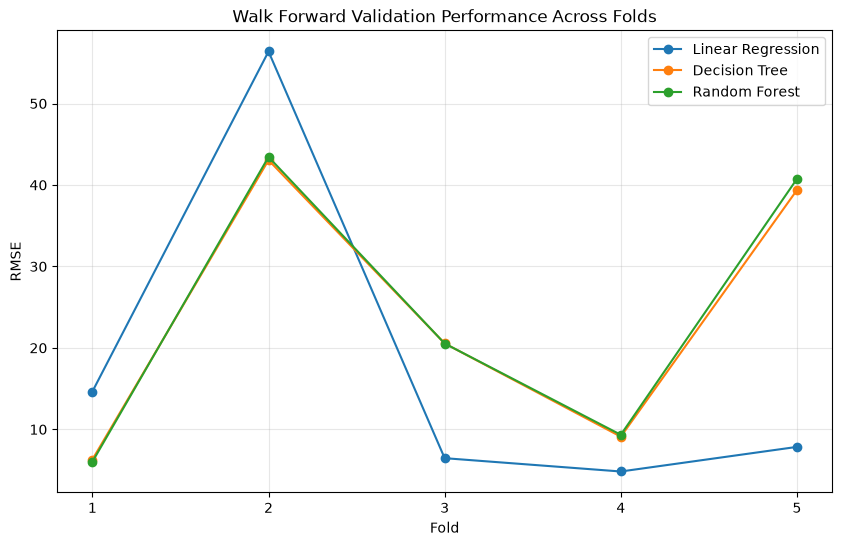

In [34]:
import matplotlib.pyplot as plt

folds = [1,2,3,4,5]

plt.figure(figsize=(10,6))

plt.plot(folds, lr_fold_rmse, marker = "o", label="Linear Regression")
plt.plot(folds, dt_fold_rmse, marker="o", label="Decision Tree")
plt.plot(folds, rf_fold_rmse, marker= "o", label="Random Forest")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks([1,2,3,4,5])
plt.grid(True, alpha = 0.3)
plt.title("Walk Forward Validation Performance Across Folds")
plt.legend()

plt.show()

#### **XGBOOST - Random Split**

In [35]:
import sys
!{sys.executable} -m pip install xgboost

'c:\Users\Dell\OneDrive\Desktop\Research' is not recognized as an internal or external command,
operable program or batch file.


In [36]:
from xgboost import  XGBRegressor

xgb_random = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_random.fit(X_train, y_train)

xgb_random_predictions = xgb_random.predict(X_test)

print(type(xgb_random))
print(xgb_random_predictions[:5])



<class 'xgboost.sklearn.XGBRegressor'>
[ 39.922867  31.41912  127.81968  195.2827    86.451935]


In [37]:
#Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb_random = mean_absolute_error(y_test, xgb_random_predictions)
mse_xgb_random = mean_squared_error(y_test, xgb_random_predictions)
rmse_xgb_random = mse_xgb_random**0.5

r2_xgb_random = r2_score(y_test, xgb_random_predictions)

print("MAE:", mae_xgb_random)
print("RMSE:", rmse_xgb_random)
print("R2:", r2_xgb_random)

MAE: 1.8750449905237554
RMSE: 2.9195659452826863
R2: 0.9983841424476195


#### **XGBOOST - Time Based Split**

In [38]:
from xgboost import  XGBRegressor

xgb_time = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_time.fit(X_train_time, y_train_time)

xgb_time_predictions = xgb_time.predict(X_test_time)

print(type(xgb_time))
print(xgb_time_predictions[:5])


<class 'xgboost.sklearn.XGBRegressor'>
[185.80759 189.05649 191.63235 191.72067 191.20981]


In [39]:
mae_xgb_time = mean_absolute_error(y_test_time, xgb_time_predictions)
mse_xgb_time = mean_squared_error(y_test_time, xgb_time_predictions)
rmse_xgb_time = mse_xgb_time**0.5

r2_xgb_time = r2_score(y_test_time, xgb_time_predictions)

print("MAE:", mae_xgb_time)
print("RMSE:", rmse_xgb_time)
print("R2:", r2_xgb_time)


MAE: 32.337197755928116
RMSE: 40.54719292999372
R2: -1.0381694428798682


In [40]:
print(
    "Training target:",
    y_train_time.min(),
    "->",
    y_train_time.max()
)

print(
    "Testing target:",
    y_test_time.min(),
    "->",
    y_test_time.max()
)

print(
    "Prediction range:",
    xgb_time_predictions.min(),
    "->",
    xgb_time_predictions.max()
)

comparison = pd.DataFrame({
    "Date": df.iloc[split_index:]["date"].values,
    "Actual": y_test_time.values,
    "Predicted": xgb_time_predictions
})

comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

print(comparison.tail(20))

Training target: 20.99180030822754 -> 196.25656127929688
Testing target: 163.66488647460938 -> 286.19000244140625
Prediction range: 163.2317 -> 194.68822
          Date      Actual   Predicted      Error
463 2025-11-20  271.489990  186.861923  84.628067
464 2025-11-21  275.920013  189.332718  86.587296
465 2025-11-24  276.970001  190.356583  86.613419
466 2025-11-25  277.549988  188.654617  88.895370
467 2025-11-26  278.850006  187.990509  90.859497
468 2025-11-28  283.100006  188.923004  94.177002
469 2025-12-01  286.190002  189.783798  96.406204
470 2025-12-02  284.149994  189.555359  94.594635
471 2025-12-03  280.700012  189.144104  91.555908
472 2025-12-04  278.779999  188.343033  90.436966
473 2025-12-05  277.890015  189.985535  87.904480
474 2025-12-08  277.179993  188.829773  88.350220
475 2025-12-09  278.779999  188.194931  90.585068
476 2025-12-10  278.029999  189.359894  88.670105
477 2025-12-11  278.279999  188.245956  90.034042
478 2025-12-12  274.109985  188.089066  86.020

#### **XGBoost - Walk Forward Validation**

In [41]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = XGBRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    
    predictions_xgb_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_xgb_wf)
        )
    rmse_xgb_wf = mean_squared_error(
    y_test_fold,
    predictions_xgb_wf
    ) ** 0.5

    rmse_scores.append(rmse_xgb_wf)

    
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_xgb_wf)
    )
    
    print(f"\n========== Fold {fold} ==========")

    print("Fold RMSE:", rmse_xgb_wf)
    print(
        "Train target:",
        y_train_fold.min(),
        "->",
        y_train_fold.max()
    )

    print(
        "Test target:",
        y_test_fold.min(),
        "->",
        y_test_fold.max()
    )

    print(
        "Prediction range:",
        predictions_xgb_wf.min(),
        "->",
        predictions_xgb_wf.max()
    )
    
    fold+=1
xgb_fold_rmse = rmse_scores.copy()
mean_rmse_xgb_wf =  np.mean(rmse_scores)  
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_xgb_wf)
print("Average R2:", np.mean(r2_scores))
    
    


========== Fold 1 ==========
Fold RMSE: 6.113356072840272
Train target: 20.99180030822754 -> 41.31612396240234
Test target: 33.7996711730957 -> 54.97304534912109
Prediction range: 34.887875 -> 41.02882

========== Fold 2 ==========
Fold RMSE: 44.55623435446541
Train target: 20.99180030822754 -> 54.97304534912109
Test target: 46.33326721191406 -> 139.3594512939453
Prediction range: 45.334816 -> 53.851185

========== Fold 3 ==========
Fold RMSE: 21.60487765715952
Train target: 20.99180030822754 -> 139.3594512939453
Test target: 113.44017791748048 -> 178.27029418945312
Prediction range: 111.54906 -> 138.88252

========== Fold 4 ==========
Fold RMSE: 12.665003229427416
Train target: 20.99180030822754 -> 178.27029418945312
Test target: 123.16194152832033 -> 196.25656127929688
Prediction range: 125.052025 -> 173.69678

========== Fold 5 ==========
Fold RMSE: 46.113929254421095
Train target: 20.99180030822754 -> 196.25656127929688
Test target: 171.83242797851562 -> 286.19000244140625
Predict

###### In this study, the evaluated tree-based models did not extrapolate meaningfully beyond the target values observed during training. As a result, they systematically underpredicted prices during the later test period, where Apple entered a higher price regime.

###### Across both chronological holdout and walk-forward validation, the evaluated tree-based models (Decision Tree, Random Forest, and XGBoost) consistently produced predictions that remained close to the maximum target values observed during training. In the final walk-forward fold, for example, XGBoost was trained on prices up to $196.26, yet its maximum prediction was $193.91 while the testing period reached $286.19. Similar behavior was observed for Decision Tree and Random Forest, resulting in systematic underprediction during later market periods and substantially higher prediction errors.

#### **Neural Network (MLP) - Random**

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.neural_network import MLPRegressor

mlp_random = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_random.fit(X_train_scaled, y_train)

mlp_random_predictions = mlp_random.predict(X_test_scaled)

print(type(mlp_random))
print(mlp_random_predictions[:5])

<class 'sklearn.neural_network._multilayer_perceptron.MLPRegressor'>
[ 40.26809485  32.215044   128.51420292 193.25302227  88.06971212]


In [44]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_random = mean_absolute_error(
    y_test,
    mlp_random_predictions
)

mse_mlp_random = mean_squared_error(
    y_test,
    mlp_random_predictions
)

rmse_mlp_random = mse_mlp_random ** 0.5

r2_mlp_random = r2_score(
    y_test,
    mlp_random_predictions
)

print("MAE:", mae_mlp_random)
print("RMSE:", rmse_mlp_random)
print("R2:", r2_mlp_random)

MAE: 1.822694746221387
RMSE: 2.7944868472688396
R2: 0.9985196287789496


###### *Initial MLP experiments produced extremely poor results when trained on unscaled features. After applying StandardScaler, RMSE improved to ≈ 2.79, demonstrating the sensitivity of neural networks to feature scaling.*

#### **Neural Network (MLP) - Time Based**

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_time_scaled = scaler.fit_transform(X_train_time)
X_test_time_scaled = scaler.transform(X_test_time)



In [46]:
from sklearn.neural_network import MLPRegressor

mlp_time = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_time.fit(X_train_time_scaled, y_train_time)

mlp_time_predictions = mlp_time.predict(X_test_time_scaled)
print(mlp_time_predictions[:5])

[186.15854613 189.49963035 192.20063021 193.42958671 193.52424606]


In [47]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_time = mean_absolute_error(
    y_test_time,
    mlp_time_predictions
)

mse_mlp_time = mean_squared_error(
    y_test_time,
    mlp_time_predictions
)

rmse_mlp_time = mse_mlp_time ** 0.5

r2_mlp_time = r2_score(
    y_test_time,
    mlp_time_predictions
)

print("MAE:", mae_mlp_time)
print("RMSE:", rmse_mlp_time)
print("R2:", r2_mlp_time)

MAE: 3.0299974453911678
RMSE: 4.983990463505491
R2: 0.9692055037237967


In [48]:
print(
    "Training target:",
    y_train_time.min(),
    "->",
    y_train_time.max()
)

print(
    "Testing target:",
    y_test_time.min(),
    "->",
    y_test_time.max()
)

print(
    "Prediction range:",
    mlp_time_predictions.min(),
    "->",
    mlp_time_predictions.max()
)

Training target: 20.99180030822754 -> 196.25656127929688
Testing target: 163.66488647460938 -> 286.19000244140625
Prediction range: 163.91408666611397 -> 285.2814650982063


###### Random validation substantially overestimates the performance of tree-based machine learning models for this financial forecasting task, while the MLP exhibited much greater robustness under time-aware validation.

###### Under chronological validation, the MLP substantially outperformed all other evaluated models (RMSE = 4.98). Diagnostic analysis showed that, unlike the Decision Tree, Random Forest, and XGBoost models, the MLP generated predictions across nearly the full range of the testing targets. Specifically, although the training data contained prices up to $196.26, the MLP produced predictions up to $285.28 while the testing period reached $286.19. This suggests that the neural network learned a continuous nonlinear mapping capable of representing the higher-price regime observed during the testing period, whereas the tree-based models consistently underpredicted future prices.

###### Across both datasets, the MLP was substantially more robust to time-aware validation than the evaluated tree-based models. However, its absolute forecasting accuracy varied by dataset, indicating that performance also depends on the underlying characteristics of the financial time series.

#### **MLP - Walk Forward Validation**

In [49]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    scaler = StandardScaler()
    
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_test_fold_scaled = scaler.transform(X_test_fold)
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state = 42)
    model.fit(X_train_fold_scaled, y_train_fold)
    
    predictions_mlp_wf = model.predict(X_test_fold_scaled)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_mlp_wf)
        )
    rmse_mlp_wf = mean_squared_error(
    y_test_fold,
    predictions_mlp_wf
    ) ** 0.5

    rmse_scores.append(rmse_mlp_wf)

    print("Fold RMSE:", rmse_mlp_wf)
    print(f"Fold {fold} R²:", r2_score(y_test_fold, predictions_mlp_wf))
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_mlp_wf)
    )
mlp_fold_rmse = rmse_scores.copy()
mean_rmse_mlp_wf =  np.mean(rmse_scores)  

print("Average MAE:", np.mean(mae_scores))
print("MAE standard deviation:", np.std(mae_scores))

print("Average RMSE:", mean_rmse_mlp_wf)
print("RMSE standard deviation:", np.std(rmse_scores))

print("Median RMSE:", np.median(rmse_scores))

print("Average R²:", np.mean(r2_scores))
print("R² standard deviation:", np.std(r2_scores))

    
    

c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold RMSE: 19.48463514127413
Fold 6 R²: -16.061781582629017
Fold RMSE: 14.732650205747795
Fold 6 R²: 0.7020594498077708
Fold RMSE: 6.228069709790947
Fold 6 R²: 0.843768435711262
Fold RMSE: 2.9171958415123416
Fold 6 R²: 0.975156684451288
Fold RMSE: 6.319886335167554
Fold 6 R²: 0.9234813238731809
Average MAE: 7.586373480276093
MAE standard deviation: 4.778672061378273
Average RMSE: 9.936487446698553
RMSE standard deviation: 6.168839793003147
Median RMSE: 6.319886335167554
Average R²: -2.523463137757103
R² standard deviation: 6.769786961624799


###### During walk-forward validation, the MLP achieved the lowest average RMSE (9.94) among all evaluated models. Although the arithmetic mean of the fold-wise R² values was negative (-2.52), this was driven almost entirely by the first fold (R² = -16.06), which was trained on only 405 observations. The remaining four folds achieved R² values between 0.70 and 0.98, indicating strong predictive performance once additional historical data became available.

###### Tree-based models appear outstanding under random validation but degrade substantially under time-aware validation.

###### The MLP remains comparatively robust across all three validation strategies, although its earliest walk-forward fold indicates that it benefits from having a larger amount of historical training data.

###### Linear Regression remains a strong baseline under time-aware validation despite not being the best model under random validation.

### **Visualization**

In [50]:
import matplotlib.pyplot as plt

models = [
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "XGBoost",
    "MLP"
]

random_rmse = [
    rmse,
    rmse_dt_random,
    rmse_rf_random,
    rmse_xgb_random,
    rmse_mlp_random
]

time_rmse = [
    rmse_time,
    rmse_dt_time,
    rmse_rf_time,
    rmse_xgb_time,
    rmse_mlp_time
]

walk_rmse = [
    mean_rmse_lr_wf,
    mean_rmse_dt_wf,
    mean_rmse_rf_wf,
    mean_rmse_xgb_wf,
    mean_rmse_mlp_wf
]

x = range(len(models))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    [i-width for i in x],
    random_rmse,
    width=width,
    label="Random Split"
)

plt.bar(
    x,
    time_rmse,
    width=width,
    label="Time-Based Split"
)

plt.bar(
    [i+width for i in x],
    walk_rmse,
    width=width,
    label="Walk-Forward"
)

plt.xticks(x, models)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Performance Under Different Validation Strategies")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

NameError: name 'rmse' is not defined

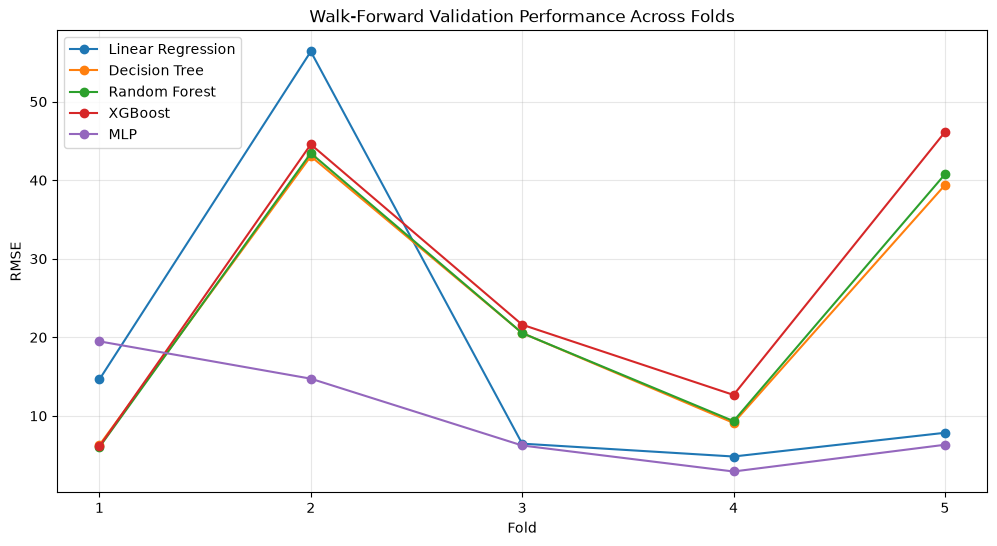

In [ ]:
import matplotlib.pyplot as plt

folds = [1,2,3,4,5]

plt.figure(figsize=(12,6))

plt.plot(
    folds,
    lr_fold_rmse,
    marker="o",
    label="Linear Regression"
)

plt.plot(
    folds,
    dt_fold_rmse,
    marker="o",
    label="Decision Tree"
)

plt.plot(
    folds,
    rf_fold_rmse,
    marker="o",
    label="Random Forest"
)

plt.plot(
    folds,
    xgb_fold_rmse,
    marker="o",
    label="XGBoost"
)

plt.plot(
    folds,
    mlp_fold_rmse,
    marker="o",
    label="MLP"
)

plt.xticks([1,2,3,4,5])
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Walk-Forward Validation Performance Across Folds")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

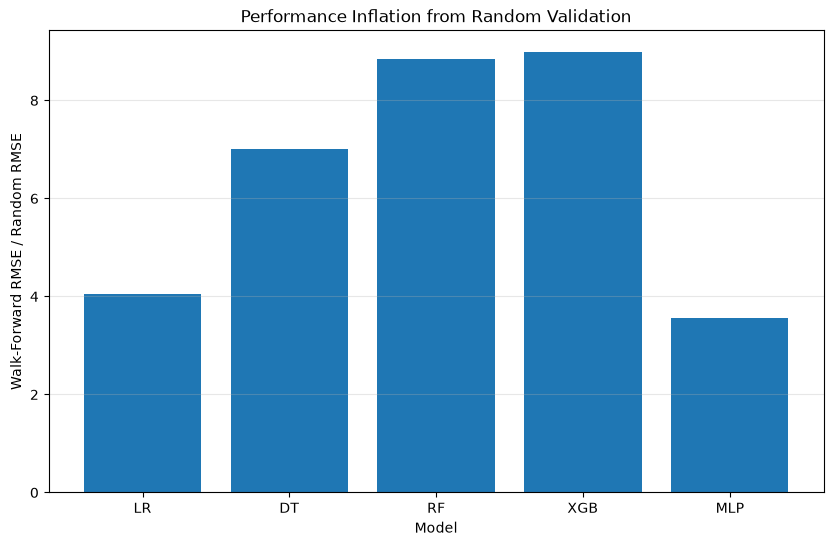

In [ ]:
inflation = [
    mean_rmse_lr_wf / rmse,
    mean_rmse_dt_wf / rmse_dt_random,
    mean_rmse_rf_wf / rmse_rf_random,
    mean_rmse_xgb_wf / rmse_xgb_random,
    mean_rmse_mlp_wf / rmse_mlp_random
]

plt.figure(figsize=(10,6))

plt.bar(
    [
        "LR",
        "DT",
        "RF",
        "XGB",
        "MLP"
    ],
    inflation
)

plt.ylabel("Walk-Forward RMSE / Random RMSE")
plt.xlabel("Model")
plt.title("Performance Inflation from Random Validation")

plt.grid(axis="y", alpha=0.3)

plt.show()

#### **LSTM EXPERIMENTS**

##### **Expeiriment 1 - Raw OHLCV**

In [ ]:
import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Prepare raw data

raw_features = [
    "open",
    "high",
    "low",
    "close",
    "volume"
]

X_raw = df[raw_features].copy()
y_raw = df[["next_day_close"]].copy()

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.80)

X_train = X_raw.iloc[:train_end]
X_validation = X_raw.iloc[train_end:validation_end]
X_test = X_raw.iloc[validation_end:]

y_train = y_raw.iloc[:train_end]
y_validation = y_raw.iloc[train_end:validation_end]
y_test = y_raw.iloc[validation_end:]

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

# Scale using training data only

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_validation_scaled = X_scaler.transform(
    X_validation
)

X_test_scaled = X_scaler.transform(
    X_test
)

y_train_scaled = y_scaler.fit_transform(
    y_train
).flatten()

y_validation_scaled = y_scaler.transform(
    y_validation
).flatten()

y_test_scaled = y_scaler.transform(
    y_test
).flatten()

# Create training sequences

def create_sequences(
    X: np.ndarray,
    y: np.ndarray,
    lookback: int
):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(
            X[i - lookback:i]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences)
    )
    
lookback = 10

X_lstm_train, y_lstm_train = create_sequences(
    X_train_scaled,
    y_train_scaled,
    lookback
)

# Preserve context at split boundaries

def create_sequences_with_context(
    previous_X: np.ndarray,
    current_X: np.ndarray,
    current_y: np.ndarray,
    lookback: int
):
    X_with_context = np.vstack([
        previous_X[-lookback:],
        current_X
    ])

    X_sequences = []

    for i in range(
        lookback,
        len(X_with_context)
    ):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(current_y)
    )

# Create validation sequences:

X_lstm_validation, y_lstm_validation = (
    create_sequences_with_context(
        previous_X=X_train_scaled,
        current_X=X_validation_scaled,
        current_y=y_validation_scaled,
        lookback=lookback
    )
)
# Create test sequences using the period immediately before the test set:

X_before_test = np.vstack([
    X_train_scaled,
    X_validation_scaled
])

X_lstm_test, y_lstm_test_scaled = (
    create_sequences_with_context(
        previous_X=X_before_test,
        current_X=X_test_scaled,
        current_y=y_test_scaled,
        lookback=lookback
    )
)

# Check the shapes:

print(
    "Train:",
    X_lstm_train.shape,
    y_lstm_train.shape
)

print(
    "Validation:",
    X_lstm_validation.shape,
    y_lstm_validation.shape
)

print(
    "Test:",
    X_lstm_test.shape,
    y_lstm_test_scaled.shape
)

# Train the LSTM properly

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model = Sequential([
    Input(
        shape=(
            lookback,
            len(raw_features)
        )
    ),
    LSTM(
        units=50
    ),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min"
)

history = model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

# Predict and inverse-transform

predictions_scaled = model.predict(
    X_lstm_test,
    verbose=0
)

lstm_predictions = (
    y_scaler.inverse_transform(
        predictions_scaled
    )
    .flatten()
)

y_lstm_test = (
    y_scaler.inverse_transform(
        y_lstm_test_scaled.reshape(-1, 1)
    )
    .flatten()
)

# Evaluation

mae_lstm_time = mean_absolute_error(
    y_lstm_test,
    lstm_predictions
)

rmse_lstm_time = mean_squared_error(
    y_lstm_test,
    lstm_predictions
) ** 0.5

r2_lstm_time = r2_score(
    y_lstm_test,
    lstm_predictions
)

print("MAE:", mae_lstm_time)
print("RMSE:", rmse_lstm_time)
print("R²:", r2_lstm_time)

print(
    "Actual range:",
    y_lstm_test.min(),
    "->",
    y_lstm_test.max()
)

print(
    "Prediction range:",
    lstm_predictions.min(),
    "->",
    lstm_predictions.max()
)

print(
    "Epochs trained:",
    len(history.history["loss"])
)

Train: (1690, 5)
Validation: (242, 5)
Test: (483, 5)
Train: (1680, 10, 5) (1680,)
Validation: (242, 10, 5) (242,)
Test: (483, 10, 5) (483,)

Epoch 1/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2071 - val_loss: 0.0419
Epoch 2/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0148 - val_loss: 0.0650
Epoch 3/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144 - val_loss: 0.0557
Epoch 4/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0136 - val_loss: 0.0402
Epoch 5/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0114 - val_loss: 0.0340
Epoch 6/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 - val_loss: 0.0347
Epoch 7/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 - val_loss: 0.0403
Epoch 8/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0084 - val_loss: 0.0466
Epoch 9/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - val_loss: 0.0467
Epoch 10/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0127 - val_loss: 0.0397
Epoch 1

##### **Experiment 2 - All Engineered Features**

In [ ]:
# 1. Prepare the data

import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

engineered_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "rsi_7",
    "rsi_14",
    "cci_7",
    "cci_14",
    "sma_50",
    "ema_50",
    "sma_100",
    "ema_100",
    "macd",
    "bollinger",
    "TrueRange",
    "atr_7",
    "atr_14",
]

X_eng = df[engineered_features].copy()
y_eng = df[["next_day_close"]].copy()

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.80)

X_train_eng = X_eng.iloc[:train_end]
X_validation_eng = X_eng.iloc[train_end:validation_end]
X_test_eng = X_eng.iloc[validation_end:]

y_train_eng = y_eng.iloc[:train_end]
y_validation_eng = y_eng.iloc[train_end:validation_end]
y_test_eng = y_eng.iloc[validation_end:]

print("Train:", X_train_eng.shape)
print("Validation:", X_validation_eng.shape)
print("Test:", X_test_eng.shape)

# 2. Scale inputs and target using training data only

X_scaler_eng = StandardScaler()
y_scaler_eng = StandardScaler()

X_train_eng_scaled = X_scaler_eng.fit_transform(X_train_eng)
X_validation_eng_scaled = X_scaler_eng.transform(X_validation_eng)
X_test_eng_scaled = X_scaler_eng.transform(X_test_eng)

y_train_eng_scaled = y_scaler_eng.fit_transform(
    y_train_eng
).flatten()

y_validation_eng_scaled = y_scaler_eng.transform(
    y_validation_eng
).flatten()

y_test_eng_scaled = y_scaler_eng.transform(
    y_test_eng
).flatten()

# 3. Create sequences

def create_sequences(X, y, lookback):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(X[i - lookback:i])
        y_sequences.append(y[i])

    return np.asarray(X_sequences), np.asarray(y_sequences)

def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    lookback
):
    X_with_context = np.vstack([
        previous_X[-lookback:],
        current_X,
    ])

    X_sequences = []

    for i in range(lookback, len(X_with_context)):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return np.asarray(X_sequences), np.asarray(current_y)

lookback = 10

X_lstm_train_eng, y_lstm_train_eng = create_sequences(
    X_train_eng_scaled,
    y_train_eng_scaled,
    lookback,
)

X_lstm_validation_eng, y_lstm_validation_eng = (
    create_sequences_with_context(
        previous_X=X_train_eng_scaled,
        current_X=X_validation_eng_scaled,
        current_y=y_validation_eng_scaled,
        lookback=lookback,
    )
)

X_before_test_eng = np.vstack([
    X_train_eng_scaled,
    X_validation_eng_scaled,
])

X_lstm_test_eng, y_lstm_test_eng_scaled = (
    create_sequences_with_context(
        previous_X=X_before_test_eng,
        current_X=X_test_eng_scaled,
        current_y=y_test_eng_scaled,
        lookback=lookback,
    )
)

print(
    "Train:",
    X_lstm_train_eng.shape,
    y_lstm_train_eng.shape,
)

print(
    "Validation:",
    X_lstm_validation_eng.shape,
    y_lstm_validation_eng.shape,
)

print(
    "Test:",
    X_lstm_test_eng.shape,
    y_lstm_test_eng_scaled.shape,
)

# 4. Build and train a fresh model

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model_eng = Sequential([
    Input(
        shape=(
            lookback,
            len(engineered_features),
        )
    ),
    LSTM(units=50),
    Dense(1),
])

model_eng.compile(
    optimizer="adam",
    loss="mse",
)

early_stop_eng = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min",
)

history_eng = model_eng.fit(
    X_lstm_train_eng,
    y_lstm_train_eng,
    validation_data=(
        X_lstm_validation_eng,
        y_lstm_validation_eng,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop_eng],
    shuffle=False,
    verbose=1,
)

# 5. Predict and inverse-transform

predictions_eng_scaled = model_eng.predict(
    X_lstm_test_eng,
    verbose=0,
)

lstm_predictions_eng = (
    y_scaler_eng.inverse_transform(
        predictions_eng_scaled
    )
    .flatten()
)

y_lstm_test_eng = (
    y_scaler_eng.inverse_transform(
        y_lstm_test_eng_scaled.reshape(-1, 1)
    )
    .flatten()
)

# 6. Evaluate

mae_lstm_eng_time = mean_absolute_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

rmse_lstm_eng_time = mean_squared_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
) ** 0.5

r2_lstm_eng_time = r2_score(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

print("MAE:", mae_lstm_eng_time)
print("RMSE:", rmse_lstm_eng_time)
print("R²:", r2_lstm_eng_time)

print(
    "Actual range:",
    y_lstm_test_eng.min(),
    "->",
    y_lstm_test_eng.max(),
)

print(
    "Prediction range:",
    lstm_predictions_eng.min(),
    "->",
    lstm_predictions_eng.max(),
)

print(
    "Epochs trained:",
    len(history_eng.history["loss"]),
)


Train: (1690, 18)
Validation: (242, 18)
Test: (483, 18)
Train: (1680, 10, 18) (1680,)
Validation: (242, 10, 18) (242,)
Test: (483, 10, 18) (483,)
Epoch 1/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.1811 - val_loss: 0.1492
Epoch 2/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0747 - val_loss: 0.0781
Epoch 3/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0740 - val_loss: 0.1390
Epoch 4/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0748 - val_loss: 0.1024
Epoch 5/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0269 - val_loss: 0.0743
Epoch 6/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0106 - val_loss: 0.0591
Epoch 7/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0077 - val_loss: 0.0491
Epoch 8/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0069 - val_loss: 0.0420
Epoch 9/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0065 - val_loss: 0.0364
Epoch 10/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0061 - val_loss: 0.0

###### Across both datasets, adding technical indicators did not improve chronological LSTM performance. The raw-OHLCV configuration achieved the lower RMSE in both cases, suggesting that the LSTM was able to extract useful temporal structure directly from recent price and volume sequences, while the additional indicators introduced redundant or less stable information.

In [ ]:
# Justified Capacity Test

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model_eng = Sequential([
    Input(
        shape=(
            lookback,
            len(engineered_features),
        )
    ),
    LSTM(units=100),
    Dense(1),
])

model_eng.compile(
    optimizer="adam",
    loss="mse",
)

early_stop_eng = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min",
)

history_eng = model_eng.fit(
    X_lstm_train_eng,
    y_lstm_train_eng,
    validation_data=(
        X_lstm_validation_eng,
        y_lstm_validation_eng,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop_eng],
    shuffle=False,
    verbose=1,
)

# 5. Predict and inverse-transform

predictions_eng_scaled = model_eng.predict(
    X_lstm_test_eng,
    verbose=0,
)

lstm_predictions_eng = (
    y_scaler_eng.inverse_transform(
        predictions_eng_scaled
    )
    .flatten()
)

y_lstm_test_eng = (
    y_scaler_eng.inverse_transform(
        y_lstm_test_eng_scaled.reshape(-1, 1)
    )
    .flatten()
)

# 6. Evaluate

mae_lstm_eng_time = mean_absolute_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

rmse_lstm_eng_time = mean_squared_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
) ** 0.5

r2_lstm_eng_time = r2_score(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

print("MAE:", mae_lstm_eng_time)
print("RMSE:", rmse_lstm_eng_time)
print("R²:", r2_lstm_eng_time)


print(
    "Actual range:",
    y_lstm_test_eng.min(),
    "->",
    y_lstm_test_eng.max(),
)

print(
    "Prediction range:",
    lstm_predictions_eng.min(),
    "->",
    lstm_predictions_eng.max(),
)

print(
    "Epochs trained:",
    len(history_eng.history["loss"]),
)


Epoch 1/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 0.1405 - val_loss: 0.4520
Epoch 2/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0399 - val_loss: 0.1721
Epoch 3/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0508 - val_loss: 0.0766
Epoch 4/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0621 - val_loss: 0.0656
Epoch 5/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0352 - val_loss: 0.0504
Epoch 6/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0376 - val_loss: 0.0249
Epoch 7/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0355 - val_loss: 0.0405
Epoch 8/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0262 - val_loss: 0.0522
Epoch 9/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0128 - val_loss: 0.0442
Epoch 10/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0065 - val_loss: 0.0294
Epoch 11/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0048 - val_loss: 0.0227
Epoch 12/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/ste

###### Increasing LSTM capacity from 50 to 100 units did not improve performance with engineered features on the Apple dataset. Instead, RMSE increased from 19.46 to 24.74 and R² declined from 0.530 to 0.241. The validation curve also indicated earlier overfitting, suggesting that the larger architecture added complexity without providing better generalization.

##### **LSTM - Walk Forward**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
import numpy as np
import random


# =========================================================
# 1. Experiment configuration
# =========================================================

SEED = 42
LOOKBACK = 10
N_SPLITS = 5
VALIDATION_RATIO = 0.20
MAX_EPOCHS = 300
BATCH_SIZE = 32
PATIENCE = 10
LSTM_UNITS = 50

raw_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
]

X_raw = df[raw_features].copy()
y_raw = df["next_day_close"].copy()

tscv = TimeSeriesSplit(n_splits=N_SPLITS)


# =========================================================
# 2. Reproducibility helper
# =========================================================

def reset_random_seeds(seed=SEED):
    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


# =========================================================
# 3. Model builder
# =========================================================

def build_lstm_model(
    lookback,
    number_of_features,
    units=LSTM_UNITS,
):
    model = Sequential([
        Input(
            shape=(
                lookback,
                number_of_features,
            )
        ),
        LSTM(units=units),
        Dense(1),
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
    )

    return model


# =========================================================
# 4. Sequence helpers
# =========================================================

def create_training_sequences(
    X,
    y,
    lookback,
):
    """
    Creates sequences entirely inside one training period.

    For target y[i], the model receives:
    X[i-lookback:i]
    """
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(
            X[i - lookback:i]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences),
    )


def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    lookback,
):
    """
    Creates one sequence for every row in the current period.

    The first current-period prediction uses the final
    lookback observations from the previous period.
    """
    X_with_context = np.concatenate(
        [
            previous_X[-lookback:],
            current_X,
        ],
        axis=0,
    )

    X_sequences = []

    for i in range(
        lookback,
        len(X_with_context),
    ):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(current_y),
    )


# =========================================================
# 5. Result storage
# =========================================================

fold_results = []

mae_scores = []
rmse_scores = []
r2_scores = []
best_epochs = []

fold2_actual = None
fold2_pred = None
fold2_dates = None


# =========================================================
# 6. Nested expanding-window walk-forward validation
# =========================================================

for fold, (train_index, test_index) in enumerate(
    tscv.split(X_raw),
    start=1,
):
    print(f"\n{'=' * 20} Fold {fold} {'=' * 20}")

    # -----------------------------------------------------
    # A. Outer chronological training and testing periods
    # -----------------------------------------------------

    X_outer_train = (
        X_raw.iloc[train_index]
        .copy()
        .reset_index(drop=True)
    )

    X_outer_test = (
        X_raw.iloc[test_index]
        .copy()
        .reset_index(drop=True)
    )

    y_outer_train = (
        y_raw.iloc[train_index]
        .copy()
        .reset_index(drop=True)
    )

    y_outer_test = (
        y_raw.iloc[test_index]
        .copy()
        .reset_index(drop=True)
    )

    test_dates = (
        df.iloc[test_index]["date"]
        .to_numpy()
        .copy()
    )

    # -----------------------------------------------------
    # B. Internal chronological train/validation split
    # -----------------------------------------------------
    # This split is used only to select the best epoch.

    validation_size = int(
        len(X_outer_train) * VALIDATION_RATIO
    )

    internal_train_end = (
        len(X_outer_train) - validation_size
    )

    if internal_train_end <= LOOKBACK:
        raise ValueError(
            f"Fold {fold} does not have enough internal "
            "training observations for the selected lookback."
        )

    X_internal_train_raw = (
        X_outer_train.iloc[:internal_train_end]
        .copy()
    )

    X_internal_val_raw = (
        X_outer_train.iloc[internal_train_end:]
        .copy()
    )

    y_internal_train_raw = (
        y_outer_train.iloc[:internal_train_end]
        .copy()
    )

    y_internal_val_raw = (
        y_outer_train.iloc[internal_train_end:]
        .copy()
    )

    # -----------------------------------------------------
    # C. Fit internal scalers on internal training only
    # -----------------------------------------------------

    internal_X_scaler = StandardScaler()
    internal_y_scaler = StandardScaler()

    X_internal_train_scaled = (
        internal_X_scaler.fit_transform(
            X_internal_train_raw
        )
    )

    X_internal_val_scaled = (
        internal_X_scaler.transform(
            X_internal_val_raw
        )
    )

    y_internal_train_scaled = (
        internal_y_scaler.fit_transform(
            y_internal_train_raw
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    y_internal_val_scaled = (
        internal_y_scaler.transform(
            y_internal_val_raw
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    # -----------------------------------------------------
    # D. Create internal training sequences
    # -----------------------------------------------------

    (
        X_internal_train_sequences,
        y_internal_train_sequences,
    ) = create_training_sequences(
        X_internal_train_scaled,
        y_internal_train_scaled,
        LOOKBACK,
    )

    # -----------------------------------------------------
    # E. Create validation sequences with training context
    # -----------------------------------------------------

    (
        X_internal_val_sequences,
        y_internal_val_sequences,
    ) = create_sequences_with_context(
        previous_X=X_internal_train_scaled,
        current_X=X_internal_val_scaled,
        current_y=y_internal_val_scaled,
        lookback=LOOKBACK,
    )

    print(
        "Internal training sequences:",
        X_internal_train_sequences.shape,
    )

    print(
        "Internal validation sequences:",
        X_internal_val_sequences.shape,
    )

    # -----------------------------------------------------
    # F. Select the best epoch using internal validation
    # -----------------------------------------------------

    reset_random_seeds()

    selection_model = build_lstm_model(
        lookback=LOOKBACK,
        number_of_features=len(raw_features),
        units=LSTM_UNITS,
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
    )

    selection_history = selection_model.fit(
        X_internal_train_sequences,
        y_internal_train_sequences,
        validation_data=(
            X_internal_val_sequences,
            y_internal_val_sequences,
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0,
    )

    best_epoch = (
        int(
            np.argmin(
                selection_history.history["val_loss"]
            )
        )
        + 1
    )

    best_validation_loss = float(
        np.min(
            selection_history.history["val_loss"]
        )
    )

    best_epochs.append(best_epoch)

    print("Selected best epoch:", best_epoch)
    print(
        "Best scaled validation loss:",
        best_validation_loss,
    )

    # The selection model is no longer used.
    del selection_model


    # =====================================================
    # G. Retrain using the complete outer training fold
    # =====================================================

    # Fit fresh scalers using every observation available
    # in the outer training fold.

    full_X_scaler = StandardScaler()
    full_y_scaler = StandardScaler()

    X_outer_train_scaled = (
        full_X_scaler.fit_transform(
            X_outer_train
        )
    )

    X_outer_test_scaled = (
        full_X_scaler.transform(
            X_outer_test
        )
    )

    y_outer_train_scaled = (
        full_y_scaler.fit_transform(
            y_outer_train
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    # -----------------------------------------------------
    # H. Create full outer-training sequences
    # -----------------------------------------------------

    (
        X_full_train_sequences,
        y_full_train_sequences,
    ) = create_training_sequences(
        X_outer_train_scaled,
        y_outer_train_scaled,
        LOOKBACK,
    )

    # -----------------------------------------------------
    # I. Create outer-test sequences using training context
    # -----------------------------------------------------

    y_test_actual = y_outer_test.to_numpy()

    (
        X_outer_test_sequences,
        _,
    ) = create_sequences_with_context(
        previous_X=X_outer_train_scaled,
        current_X=X_outer_test_scaled,
        current_y=y_test_actual,
        lookback=LOOKBACK,
    )

    print(
        "Full training sequences:",
        X_full_train_sequences.shape,
    )

    print(
        "Outer test sequences:",
        X_outer_test_sequences.shape,
    )

    print(
        "Training target range:",
        y_outer_train.min(),
        "to",
        y_outer_train.max(),
    )

    print(
        "Testing target range:",
        y_outer_test.min(),
        "to",
        y_outer_test.max(),
    )

    # -----------------------------------------------------
    # J. Build and train a fresh final model
    # -----------------------------------------------------

    reset_random_seeds()

    final_model = build_lstm_model(
        lookback=LOOKBACK,
        number_of_features=len(raw_features),
        units=LSTM_UNITS,
    )

    final_history = final_model.fit(
        X_full_train_sequences,
        y_full_train_sequences,
        epochs=best_epoch,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
    )

    # -----------------------------------------------------
    # K. Predict the untouched outer test fold
    # -----------------------------------------------------

    predictions_scaled = final_model.predict(
        X_outer_test_sequences,
        verbose=0,
    )

    predictions = (
        full_y_scaler.inverse_transform(
            predictions_scaled
        )
        .flatten()
    )

    # -----------------------------------------------------
    # L. Save Fold 2 for later analysis
    # -----------------------------------------------------

    if fold == 2:
        fold2_actual = y_test_actual.copy()
        fold2_pred = predictions.copy()
        fold2_dates = test_dates.copy()

    # -----------------------------------------------------
    # M. Evaluate in original price units
    # -----------------------------------------------------

    mae = mean_absolute_error(
        y_test_actual,
        predictions,
    )

    rmse = (
        mean_squared_error(
            y_test_actual,
            predictions,
        )
        ** 0.5
    )

    r2 = r2_score(
        y_test_actual,
        predictions,
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    fold_results.append({
        "Fold": fold,
        "Train Size": len(train_index),
        "Test Size": len(test_index),
        "Best Epoch": best_epoch,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Train Target Min": y_outer_train.min(),
        "Train Target Max": y_outer_train.max(),
        "Test Target Min": y_outer_test.min(),
        "Test Target Max": y_outer_test.max(),
        "Prediction Min": predictions.min(),
        "Prediction Max": predictions.max(),
    })

    print("Prediction range:", predictions.min(), "to", predictions.max())
    print("Fold MAE:", mae)
    print("Fold RMSE:", rmse)
    print("Fold R²:", r2)

    del final_model


# =========================================================
# 7. Final walk-forward results
# =========================================================

lstm_raw_fold_rmse = rmse_scores.copy()
mean_rmse_lstm_raw_wf = np.mean(rmse_scores)

print("\n" + "=" * 55)
print("Final LSTM Walk-Forward Results")
print("=" * 55)

print("Average MAE:", np.mean(mae_scores))
print("MAE standard deviation:", np.std(mae_scores))

print("Average RMSE:", mean_rmse_lstm_raw_wf)
print("RMSE standard deviation:", np.std(rmse_scores))

print("Median RMSE:", np.median(rmse_scores))

print("Average R²:", np.mean(r2_scores))
print("R² standard deviation:", np.std(r2_scores))

print("Selected epochs:", best_epochs)
print("Average selected epoch:", np.mean(best_epochs))


==================== Fold 1 ====================
Internal training sequences: (314, 10, 5)
Internal validation sequences: (81, 10, 5)
Selected best epoch: 91
Best scaled validation loss: 0.03293202072381973
Full training sequences: (395, 10, 5)
Outer test sequences: (402, 10, 5)
Training target range: 20.99180030822754 to 41.31612396240234
Testing target range: 33.7996711730957 to 54.97304534912109
Prediction range: 34.356102 to 48.90775
Fold MAE: 1.6617673143225522
Fold RMSE: 2.167239594870503
Fold R²: 0.7889167970897004

==================== Fold 2 ====================
Internal training sequences: (636, 10, 5)
Internal validation sequences: (161, 10, 5)
Selected best epoch: 32
Best scaled validation loss: 0.02083304151892662
Full training sequences: (797, 10, 5)
Outer test sequences: (402, 10, 5)
Training target range: 20.99180030822754 to 54.97304534912109
Testing target range: 46.33326721191406 to 139.3594512939453
Prediction range: 47.27008 to 61.599983
Fold MAE: 29.0895049631299

###### *Under nested expanding-window validation, the raw-OHLCV LSTM achieved a mean RMSE of 14.44 and a median RMSE of 8.44. Performance varied substantially across folds, with RMSE ranging from 2.17 to 38.22. The largest error occurred in the second fold, where the training targets reached only $54.97 while the testing period reached $139.36; the model's maximum prediction was only $61.60. In later folds, the LSTM demonstrated stronger extrapolation, particularly in the final fold, where it generated predictions up to $267.42 despite the training targets reaching only $196.26. These results indicate that the LSTM could adapt to new price levels, but its effectiveness depended strongly on the magnitude and nature of the market-regime transition.*

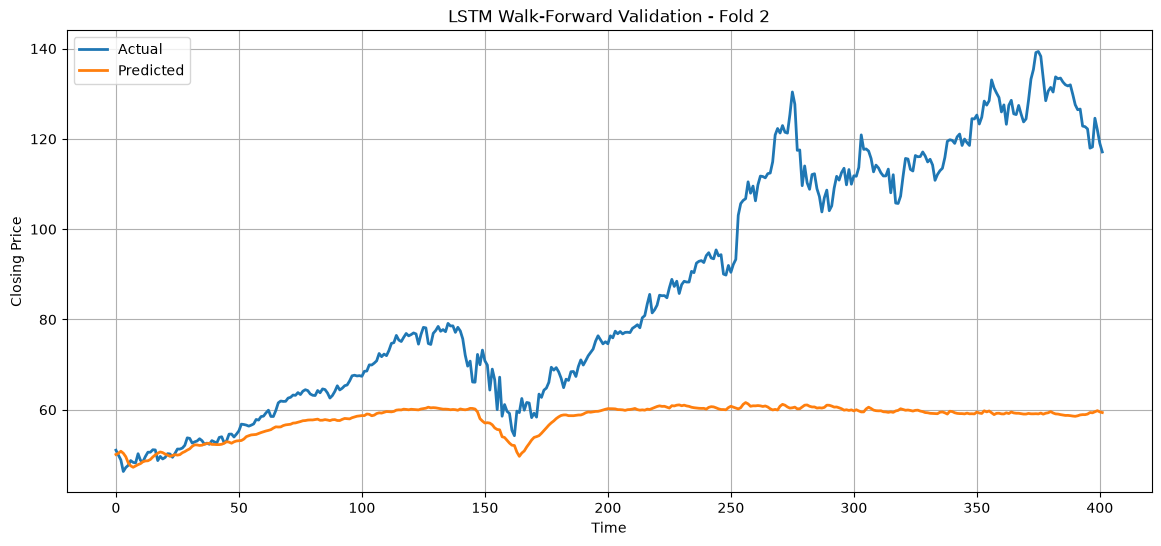

In [ ]:
#plotting the actual and predicted fold 2

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(fold2_actual, label="Actual", linewidth = 2)
plt.plot(fold2_pred, label="Predicted", linewidth = 2)

plt.title("LSTM Walk-Forward Validation - Fold 2")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()